In [1]:

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [3]:
# Load dataset
data = pd.read_csv("C:\\Users\\samar\\OneDrive\\Desktop\\project\\True.csv")

print("Shape:", data.shape)
data.head()

Shape: (21417, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'\[.*?\]', '', text)
        text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
        text = re.sub(r'\w*\d\w*', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return ""

data['text'] = data['text'].apply(clean_text)
data['text'].head()

0    washington reuters the head of a conservative ...
1    washington reuters transgender people will be ...
2    washington reuters the special counsel investi...
3    washington reuters trump campaign adviser geor...
4    seattlewashington reuters president donald tru...
Name: text, dtype: object

In [13]:
X = data['text']
y = data['subject']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 17133
Testing size: 4284


In [14]:
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((17133, 67998), (4284, 67998))

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
    # "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)  # Removed for speed
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n===== {name} =====")
    print("✅ Accuracy:", acc)
    print("📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("📄 Classification Report:\n", classification_report(y_test, y_pred))


===== Logistic Regression =====
✅ Accuracy: 0.9428104575163399
📊 Confusion Matrix:
 [[2104  151]
 [  94 1935]]
📄 Classification Report:
               precision    recall  f1-score   support

politicsNews       0.96      0.93      0.94      2255
   worldnews       0.93      0.95      0.94      2029

    accuracy                           0.94      4284
   macro avg       0.94      0.94      0.94      4284
weighted avg       0.94      0.94      0.94      4284


===== Naive Bayes =====
✅ Accuracy: 0.9274042950513539
📊 Confusion Matrix:
 [[2088  167]
 [ 144 1885]]
📄 Classification Report:
               precision    recall  f1-score   support

politicsNews       0.94      0.93      0.93      2255
   worldnews       0.92      0.93      0.92      2029

    accuracy                           0.93      4284
   macro avg       0.93      0.93      0.93      4284
weighted avg       0.93      0.93      0.93      4284



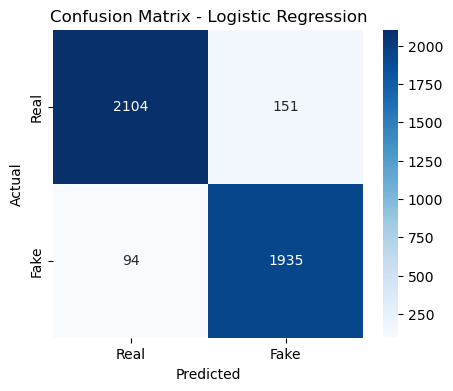

In [18]:
# Confusion Matrix for Logistic Regression
log_reg = models["Logistic Regression"]
y_pred_log = log_reg.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

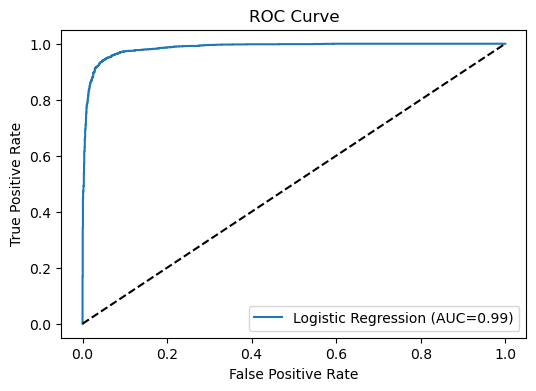

In [23]:
# ROC Curve for Logistic Regression

# Binarize y_test: 1 if 'worldnews', 0 otherwise
y_test_bin = (y_test == "worldnews").astype(int)

y_prob = log_reg.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
auc_score = roc_auc_score(y_test_bin, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc_score:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()